# Predicción del Consumo de Gas Envasado en Tierra del Fuego

## Análisis Exploratorio de Datos (EDA)

En esta etapa se realiza un análisis exploratorio del dataset integrado de consumo de gas y variables climáticas, con el objetivo de identificar patrones, relaciones entre variables y posibles factores que influyen en el consumo mensual de gas envasado.

In [ ]:
# ==========================================================
# Importación de librerías
# ==========================================================
# Se importan las bibliotecas necesarias para la manipulación,
# análisis y visualización de datos.
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset_final_gas_clima_tdf .csv to dataset_final_gas_clima_tdf .csv


In [ ]:
import os

os.listdir("/content")

['.config', 'dataset_final_gas_clima_tdf .csv', 'sample_data']

In [ ]:
# ===# ==========================================================
# Carga del dataset
# ==========================================================
# Se carga el dataset final integrado generado durante
# la etapa de preprocesamiento.
# ==========================================================

import pandas as pd

df = pd.read_csv("dataset_final_gas_clima_tdf .csv")

df.head()

,mes,año,consumo_gas_kg,cantidad_usuarios,temp_max_rg,temp_min_rg,temp_media_rg,precipitacion_rg,nieve_rg,temp_max_ush,temp_min_ush,temp_media_ush,precipitacion_ush,nieve_ush
0,ENERO,2014,619090.0,4868.0,14.6,4.4,9.4,32.0,0,8.5,7.3,7.9,40.8,0
1,FEBRERO,2014,645720.0,4966.0,15.7,5.6,10.4,36.2,0,9.2,8.0,8.6,24.6,0
2,MARZO,2014,696210.0,4982.0,12.9,3.2,7.5,51.0,0,6.7,5.7,6.2,115.0,1
3,ABRIL,2014,717420.0,4888.0,10.6,1.8,5.7,29.0,0,6.6,5.6,6.1,24.8,1
4,MAYO,2014,1377010.0,5106.0,7.1,0.3,3.6,25.0,0,4.9,3.8,4.4,36.8,3


In [ ]:
# ==========================================================
# Información general del dataset
# ==========================================================
# Se analizan las dimensiones, tipos de datos y cantidad
# de registros disponibles en el conjunto de datos.
# ==========================================================

print("Dimensiones del dataset:")
print(df.shape)

print("\nInformación general:")
df.info()

Dimensiones del dataset:
(144, 14)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mes                144 non-null    object 
 1   año                144 non-null    int64  
 2   consumo_gas_kg     144 non-null    float64
 3   cantidad_usuarios  144 non-null    float64
 4   temp_max_rg        144 non-null    float64
 5   temp_min_rg        144 non-null    float64
 6   temp_media_rg      144 non-null    float64
 7   precipitacion_rg   144 non-null    float64
 8   nieve_rg           144 non-null    int64  
 9   temp_max_ush       144 non-null    float64
 10  temp_min_ush       144 non-null    float64
 11  temp_media_ush     144 non-null    float64
 12  precipitacion_ush  144 non-null    float64
 13  nieve_ush          144 non-null    int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 15.9+ KB


In [ ]:
# ==========================================================
# Verificación de valores faltantes
# ==========================================================
# Se comprueba la existencia de valores nulos en cada
# variable del dataset.
# ==========================================================

df.isnull().sum()

,0
mes,0
año,0
consumo_gas_kg,0
cantidad_usuarios,0
temp_max_rg,0
temp_min_rg,0
temp_media_rg,0
precipitacion_rg,0
nieve_rg,0
temp_max_ush,0


In [ ]:
# ==========================================================
# Estadísticos descriptivos
# ==========================================================
# Se calculan medidas descriptivas básicas para conocer
# el comportamiento general de las variables numéricas.
# ==========================================================

df.describe()

,año,consumo_gas_kg,cantidad_usuarios,temp_max_rg,temp_min_rg,temp_media_rg,precipitacion_rg,nieve_rg,temp_max_ush,temp_min_ush,temp_media_ush,precipitacion_ush,nieve_ush
count,144.000000,1.440000e+02,144.000000,144.00000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,2019.500000,1.859668e+06,7032.907828,10.67500,1.784028,6.150694,24.751389,1.152778,10.386528,2.362361,6.168889,46.756944,2.270833
std,3.464102,7.016769e+05,937.499694,4.68841,3.009511,3.835316,18.145877,2.219807,4.560025,2.925157,3.072675,26.073719,2.964165
min,2014.000000,6.190900e+05,4868.000000,-0.40000,-6.600000,-3.300000,1.000000,0.000000,-0.360000,-7.800000,-2.930000,3.500000,0.000000
25%,2016.750000,1.421826e+06,6315.500000,6.67500,-0.500000,2.975000,11.350000,0.000000,6.700000,0.475000,3.760000,29.150000,0.000000
50%,2019.500000,1.603248e+06,7115.000000,11.05000,1.600000,6.250000,19.950000,0.000000,10.850000,2.300000,6.450000,40.600000,1.000000
75%,2022.250000,2.529596e+06,7905.250000,15.02500,4.425000,9.825000,34.000000,1.000000,13.900000,5.000000,8.900000,57.425000,4.000000
max,2025.000000,3.187302e+06,8489.000000,18.00000,7.100000,12.300000,87.400000,13.000000,21.900000,8.000000,11.900000,139.700000,11.000000


In [ ]:
# ==========================================================
# Matriz de correlación
# ==========================================================
# Se analiza la relación existente entre las variables
# numéricas del dataset mediante correlación de Pearson.
# ==========================================================

corr = df.corr(numeric_only=True)

corr

,año,consumo_gas_kg,cantidad_usuarios,temp_max_rg,temp_min_rg,temp_media_rg,precipitacion_rg,nieve_rg,temp_max_ush,temp_min_ush,temp_media_ush,precipitacion_ush,nieve_ush
año,1.000000,0.387645,0.291865,0.029623,-0.058525,-0.023238,-0.180846,0.037286,0.264454,-0.346088,0.003653,0.222738,-0.035754
consumo_gas_kg,0.387645,1.000000,0.499673,-0.748796,-0.760338,-0.764481,-0.176773,0.530344,-0.531855,-0.717237,-0.696782,-0.177012,0.564261
cantidad_usuarios,0.291865,0.499673,1.000000,-0.028609,-0.103317,-0.055398,-0.166530,0.127282,0.069914,-0.040472,0.047471,-0.121550,0.021793
temp_max_rg,0.029623,-0.748796,-0.028609,1.000000,0.953283,0.983201,0.013159,-0.575809,0.807187,0.814058,0.957026,0.205635,-0.716461
temp_min_rg,-0.058525,-0.760338,-0.103317,0.953283,1.000000,0.974936,0.161336,-0.563215,0.771578,0.831900,0.940207,0.234832,-0.675006
temp_media_rg,-0.023238,-0.764481,-0.055398,0.983201,0.974936,1.000000,0.087345,-0.545577,0.799451,0.822459,0.954747,0.202843,-0.693042
precipitacion_rg,-0.180846,-0.176773,-0.166530,0.013159,0.161336,0.087345,1.000000,-0.045300,-0.031275,0.117674,0.028826,0.257185,-0.064929
nieve_rg,0.037286,0.530344,0.127282,-0.575809,-0.563215,-0.545577,-0.045300,1.000000,-0.492099,-0.483342,-0.574436,-0.091203,0.571824
temp_max_ush,0.264454,-0.531855,0.069914,0.807187,0.771578,0.799451,-0.031275,-0.492099,1.000000,0.470182,0.866411,0.006978,-0.633915
temp_min_ush,-0.346088,-0.717237,-0.040472,0.814058,0.831900,0.822459,0.117674,-0.483342,0.470182,1.000000,0.826302,0.073675,-0.609606


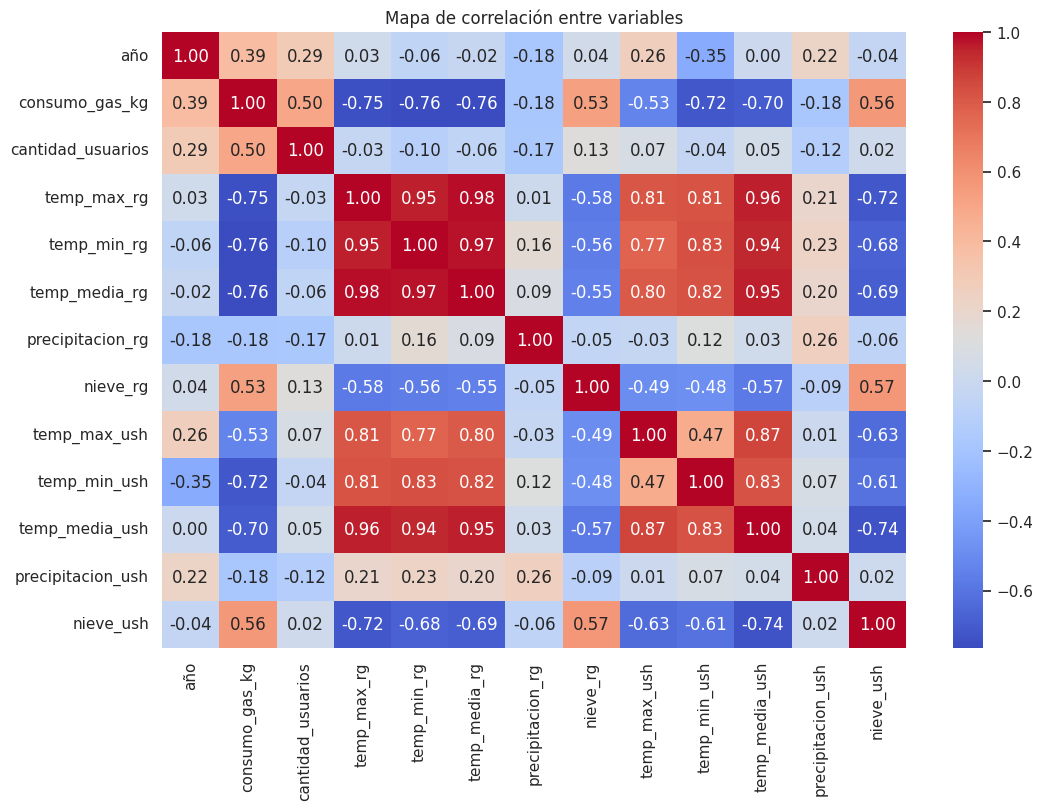

In [ ]:
# ==========================================================
# Mapa de calor de correlaciones
# ==========================================================
# Permite visualizar gráficamente la intensidad de las
# relaciones entre variables.
# ==========================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación entre variables")
plt.show()

# Conclusiones de la matriz de correlación

- El consumo de gas presenta una fuerte correlación negativa con las variables de temperatura de Río Grande y Ushuaia.
- La temperatura media de Río Grande (-0.76) y la temperatura mínima de Río Grande (-0.76) muestran las relaciones más fuertes con la variable objetivo.
- Las variables asociadas a días de nieve presentan correlaciones positivas moderadas, indicando que una mayor cantidad de días con nieve se relaciona con un incremento en el consumo de gas.
- Las precipitaciones presentan correlaciones débiles, por lo que su aporte predictivo podría ser limitado.
- Los resultados obtenidos son consistentes con el comportamiento esperado del consumo residencial de gas en una provincia con clima frío como Tierra del Fuego.

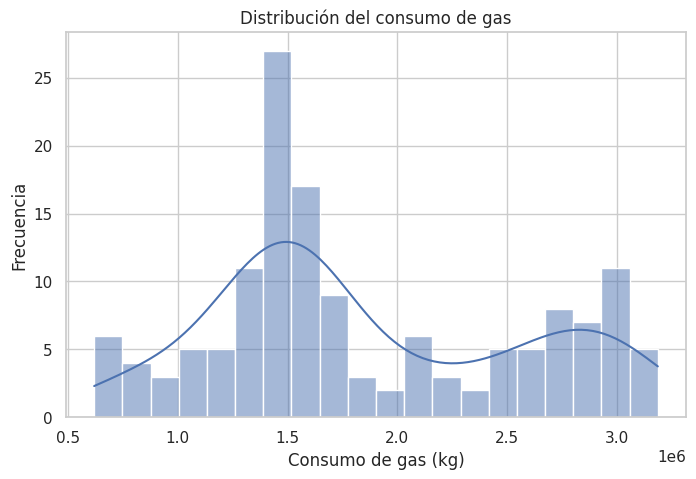

In [ ]:
# ==========================================================
# Distribución del consumo de gas
# ==========================================================
# Permite observar la forma de la distribución de la variable objetivo.
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(df["consumo_gas_kg"], bins=20, kde=True)

plt.title("Distribución del consumo de gas")
plt.xlabel("Consumo de gas (kg)")
plt.ylabel("Frecuencia")

plt.show()

# Conclusiones de la distribución del consumo

- La variable consumo_gas_kg presenta una distribución amplia con valores comprendidos entre aproximadamente 600.000 kg y 3.200.000 kg.
- Se observan distintos niveles de consumo a lo largo del período analizado, lo que aporta variabilidad suficiente para el entrenamiento de modelos predictivos.

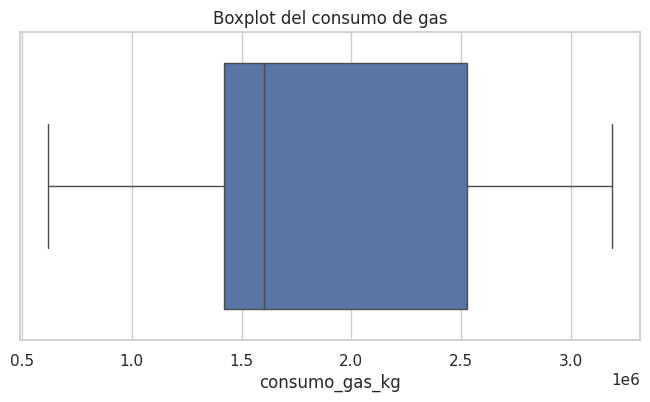

In [ ]:
# ==========================================================
# Detección de valores atípicos
# ==========================================================
# Permite identificar posibles valores extremos en la variable objetivo.
# ==========================================================

plt.figure(figsize=(8,4))

sns.boxplot(x=df["consumo_gas_kg"])

plt.title("Boxplot del consumo de gas")

plt.show()

# Conclusiones de la detección de valores atípicos

- No se observan valores atípicos extremos en la variable consumo_gas_kg.
- Los registros disponibles son consistentes y no requieren eliminación de observaciones.
- La calidad de los datos resulta adecuada para la etapa de modelado.

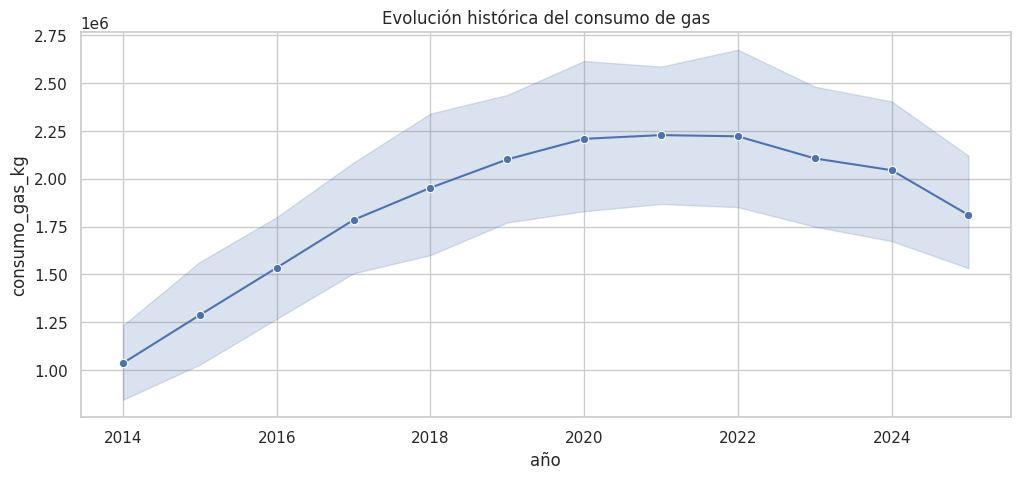

In [ ]:
# ==========================================================
# Evolución temporal del consumo
# ==========================================================
# Se analiza el comportamiento histórico del consumo de gas.
# ==========================================================

plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="año",
    y="consumo_gas_kg",
    marker="o"
)

plt.title("Evolución histórica del consumo de gas")

plt.show()

# Conclusiones de la evolución histórica

- Se observa un crecimiento sostenido del consumo de gas entre 2014 y 2021.
- A partir de 2022 el consumo muestra una leve disminución.
- La tendencia observada podría estar asociada a variaciones en la cantidad de usuarios y a cambios en las condiciones climáticas.
- El comportamiento temporal evidencia que existen patrones históricos que pueden ser aprovechados por modelos predictivos.

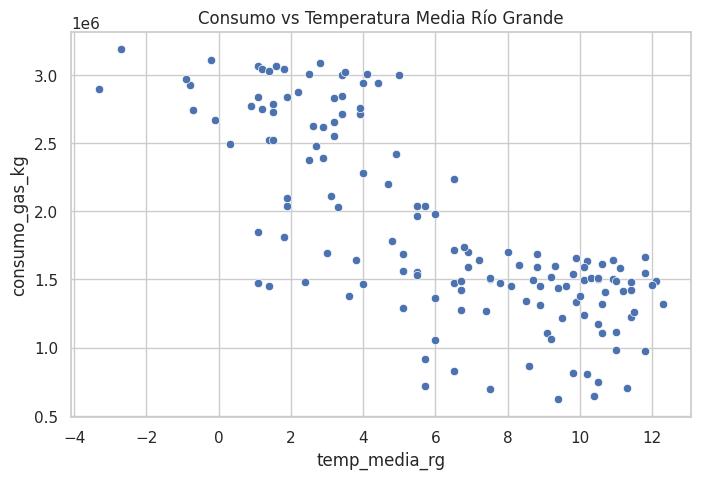

In [ ]:
# ==========================================================
# Relación entre consumo y temperatura media de Río Grande
# ==========================================================
# Permite visualizar la asociación entre la temperatura
# promedio y el consumo de gas.
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="temp_media_rg",
    y="consumo_gas_kg"
)

plt.title("Consumo vs Temperatura Media Río Grande")

plt.show()

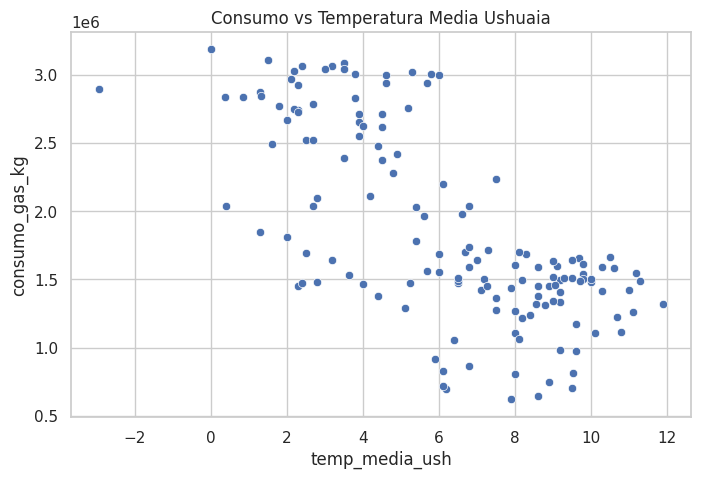

In [ ]:
# ==========================================================
# Relación entre consumo y temperatura media de Ushuaia
# ==========================================================
# Permite visualizar la asociación entre la temperatura
# promedio y el consumo de gas.
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="temp_media_ush",
    y="consumo_gas_kg"
)

plt.title("Consumo vs Temperatura Media Ushuaia")

plt.show()

# Conclusiones de los gráficos de dispersión

- Se observa una tendencia descendente entre la temperatura media y el consumo de gas.
- A medida que aumenta la temperatura media, el consumo de gas disminuye.
- La relación visual observada coincide con los coeficientes de correlación obtenidos previamente.
- Los gráficos sugieren que la temperatura constituye una de las variables más relevantes para la predicción del consumo de gas.
- La correlación negativa observada indica que las temperaturas más bajas se asocian con mayores niveles de consumo de gas.


# Conclusión general del análisis exploratorio (EDA)

- El dataset presenta 144 registros y 14 variables sin valores faltantes.
- No se detectaron valores atípicos extremos que requieran tratamiento.
- Las variables de temperatura muestran una fuerte relación inversa con el consumo de gas.
- La nieve presenta una relación positiva moderada con el consumo, especialmente en Ushuaia.
- El consumo evidencia un comportamiento estacional coherente con las condiciones climáticas de Tierra del Fuego.
- Los resultados sugieren que las variables climáticas constituyen predictores relevantes para la construcción de modelos de aprendizaje automático orientados a la predicción del consumo de gas.

# Preprocesamiento de datos

#Codificación cíclica de la variable mes

La variable mes presenta una naturaleza cíclica, ya que diciembre (12) y enero (1) corresponden a períodos consecutivos. Si se utiliza únicamente el número de mes, el modelo interpreta que existe una gran distancia entre ambos valores.

Para representar correctamente la estacionalidad anual, se aplicará una transformación trigonométrica mediante las variables mes_sin y mes_cos:

mes_sin = sin(2π × mes / 12)
mes_cos = cos(2π × mes / 12)

Esta técnica permite conservar la relación cíclica entre los meses del año y mejorar la capacidad del modelo para capturar patrones estacionales asociados al consumo de gas.

In [ ]:
# Preprocesamiento de variables temporales
# Se convierte la variable mes a formato numérico y luego
# se generan variables cíclicas para representar correctamente
# la estacionalidad anual.


meses = {
    "ENERO": 1,
    "FEBRERO": 2,
    "MARZO": 3,
    "ABRIL": 4,
    "MAYO": 5,
    "JUNIO": 6,
    "JULIO": 7,
    "AGOSTO": 8,
    "SEPTIEMBRE": 9,
    "OCTUBRE": 10,
    "NOVIEMBRE": 11,
    "DICIEMBRE": 12
}

df["mes_num"] = df["mes"].map(meses)

# Variables cíclicas del mes
df["mes_sin"] = np.sin(2 * np.pi * df["mes_num"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes_num"] / 12)

# Se elimina la columna original en formato texto
df = df.drop(columns=["mes"])

# Se ordena el dataset cronológicamente
df = df.sort_values(
    by=["año", "mes_num"]
).reset_index(drop=True)

df.head()

,año,consumo_gas_kg,cantidad_usuarios,temp_max_rg,temp_min_rg,temp_media_rg,precipitacion_rg,nieve_rg,temp_max_ush,temp_min_ush,temp_media_ush,precipitacion_ush,nieve_ush,mes_num,mes_sin,mes_cos
0,2014,619090.0,4868.0,14.6,4.4,9.4,32.0,0,8.5,7.3,7.9,40.8,0,1,0.500000,8.660254e-01
1,2014,645720.0,4966.0,15.7,5.6,10.4,36.2,0,9.2,8.0,8.6,24.6,0,2,0.866025,5.000000e-01
2,2014,696210.0,4982.0,12.9,3.2,7.5,51.0,0,6.7,5.7,6.2,115.0,1,3,1.000000,6.123234e-17
3,2014,717420.0,4888.0,10.6,1.8,5.7,29.0,0,6.6,5.6,6.1,24.8,1,4,0.866025,-5.000000e-01
4,2014,1377010.0,5106.0,7.1,0.3,3.6,25.0,0,4.9,3.8,4.4,36.8,3,5,0.500000,-8.660254e-01


In [ ]:
# Definición de variables predictoras y variable objetivo
# Se separa la variable objetivo consumo_gas_kg del resto
# de variables predictoras utilizadas para entrenar los modelos.


X = df.drop(columns=["consumo_gas_kg"])

y = df["consumo_gas_kg"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (144, 15)
Dimensiones de y: (144,)


In [ ]:
# Preparación temporal de variables
# Se ordena el dataset por año y mes para respetar
# la secuencia cronológica de los registros.
# Luego se separan las variables predictoras y la variable objetivo.

df = df.sort_values(
    by=["año", "mes_num"]
).reset_index(drop=True)

# Variables predictoras
X = df.drop(columns=["consumo_gas_kg"])

# Variable objetivo
y = df["consumo_gas_kg"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (144, 15)
Dimensiones de y: (144,)


In [ ]:
# División temporal Train/Test
# Se utiliza una división temporal para entrenar con
# los primeros años del dataset y evaluar con los años finales.
# Esta estrategia evita mezclar registros futuros dentro del entrenamiento.

anio_corte = 2024

X_train = X[df["año"] < anio_corte]
X_test = X[df["año"] >= anio_corte]

y_train = y[df["año"] < anio_corte]
y_test = y[df["año"] >= anio_corte]

print("Registros de entrenamiento:", X_train.shape[0])
print("Registros de prueba:", X_test.shape[0])

print("Años entrenamiento:",
      df.loc[df["año"] < anio_corte, "año"].min(),
      "-",
      df.loc[df["año"] < anio_corte, "año"].max())

print("Años prueba:",
      df.loc[df["año"] >= anio_corte, "año"].min(),
      "-",
      df.loc[df["año"] >= anio_corte, "año"].max())

Registros de entrenamiento: 120
Registros de prueba: 24
Años entrenamiento: 2014 - 2023
Años prueba: 2024 - 2025


In [ ]:
# Escalado para Regresión Lineal
# El escalado se aplica únicamente para el modelo de Regresión Lineal.
# El escalador se ajusta solo con los datos de entrenamiento
# y luego se aplica al conjunto de prueba para evitar fuga de información.


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelado predictivo

En esta etapa se entrenan y evalúan distintos modelos de aprendizaje automático para predecir el consumo mensual de gas en Tierra del Fuego.

In [ ]:
# ==========================================================
# MODELO N°1: Regresión Lineal Multiple
# ==========================================================
# Se entrena un modelo de regresión lineal multiple utilizando
# los datos de entrenamiento previamente preparados.
# ==========================================================

from sklearn.linear_model import LinearRegression

# Creación del modelo
modelo_lr = LinearRegression()

# Entrenamiento del modelo
modelo_lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# ==========================================================
# Predicciones con Regresión Lineal Multiple
# ==========================================================
# Se generan predicciones sobre el conjunto de prueba.
# ==========================================================

y_pred_lr = modelo_lr.predict(X_test_scaled)

In [ ]:
# ==========================================================
# Evaluación del modelo
# ==========================================================
# Se calculan métricas para medir el desempeño del modelo.
# ==========================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

MAE: 192844.8387801466
MSE: 60691581612.93197
RMSE: 246356.6147131673
R²: 0.8500718085517787


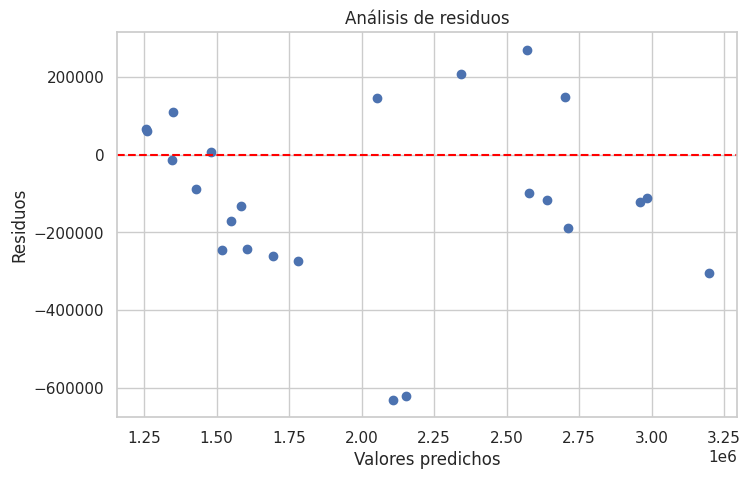

In [ ]:
# ==================================================
# Análisis de residuos
# ==================================================
# Se analiza la distribución de los errores del modelo.
# Los residuos corresponden a la diferencia entre
# los valores reales y los valores predichos.

residuos = y_test - y_pred_lr

plt.figure(figsize=(8,5))
plt.scatter(y_pred_lr, residuos)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Análisis de residuos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")

plt.show()

#Conclusiones del análisis de residuos

• Los residuos se distribuyen tanto por encima como por debajo de la línea de referencia ubicada en cero, sin evidenciar un sesgo sistemático de sobreestimación o subestimación.

• No se observan patrones estructurados ni tendencias claramente definidas en la dispersión de los errores, lo que sugiere que el modelo representa adecuadamente la relación entre las variables predictoras y el consumo de gas.

• Existen algunos registros con errores de mayor magnitud, particularmente un residuo negativo aislado, aunque estos casos no predominan dentro del conjunto de prueba.

• La distribución general de los residuos respalda la capacidad de generalización del modelo y resulta consistente con el desempeño observado en las métricas de evaluación.

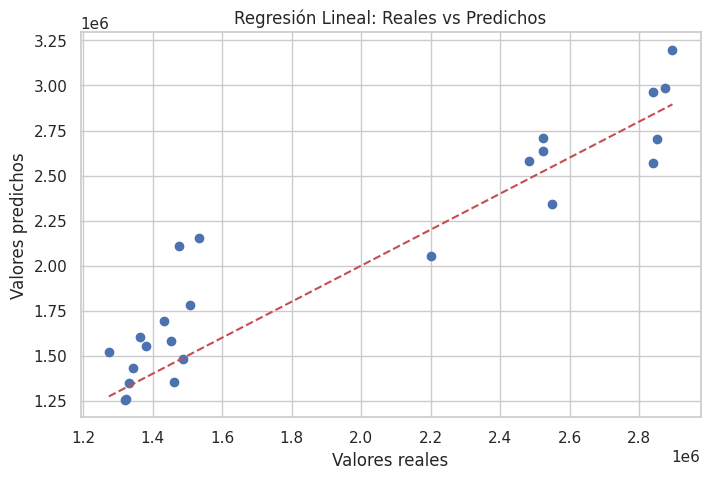

In [ ]:
# Comparación entre valores reales y predichos

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal: Reales vs Predichos")

plt.show()

#Conclusiones del gráfico de predicción

• Se observa una asociación positiva clara entre los valores reales y los valores predichos, evidenciando que la Regresión Lineal logró capturar adecuadamente la tendencia general del consumo mensual de gas.

• La mayoría de los registros se ubican próximos a la línea ideal de predicción, lo que indica una buena concordancia entre los valores observados y estimados.

• Las mayores diferencias se presentan en algunos registros puntuales, principalmente en consumos intermedios y altos, aunque no afectan significativamente el comportamiento global del modelo.

• La distribución de los puntos resulta consistente con el coeficiente de determinación R² = 0,85 obtenido durante la evaluación, confirmando una elevada capacidad explicativa sobre los datos de prueba.

#Conclusiones de la evaluación del modelo Regresión Lineal Multiple

La Regresión Lineal Múltiple obtuvo un coeficiente de determinación R² de 0,85, indicando que explica aproximadamente el 85 % de la variabilidad observada en el consumo mensual de gas envasado.

Asimismo, presentó valores reducidos de MAE y RMSE, evidenciando una buena precisión predictiva sobre el conjunto de prueba.

La comparación entre valores reales y predichos, junto con el análisis de residuos, muestra que el modelo logra representar adecuadamente la relación existente entre las variables climáticas, temporales y operativas consideradas en el estudio.

En función de los resultados obtenidos, la Regresión Lineal Múltiple se presenta como una alternativa sólida para la predicción del consumo mensual de gas, mostrando una adecuada capacidad de ajuste y generalización.


In [ ]:
# ==================================================
# MODELO N°2: Árbol de Decisión para Regresión
# ==================================================
# Se entrena un modelo de Árbol de Decisión para
# predecir el consumo de gas.

from sklearn.tree import DecisionTreeRegressor

modelo_dt = DecisionTreeRegressor(
    random_state=42
)

modelo_dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
# ==================================================
# Predicciones con Árbol de Decisión
# ==================================================
# Se generan predicciones sobre el conjunto de prueba.

y_pred_dt = modelo_dt.predict(X_test)

In [ ]:
# ==================================================
# Evaluación del modelo
# ==================================================
# Se calculan métricas para medir el desempeño.

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

MAE: 199675.29924242423
MSE: 62857702598.094
RMSE: 250714.38450574392
R²: 0.8447207764459653


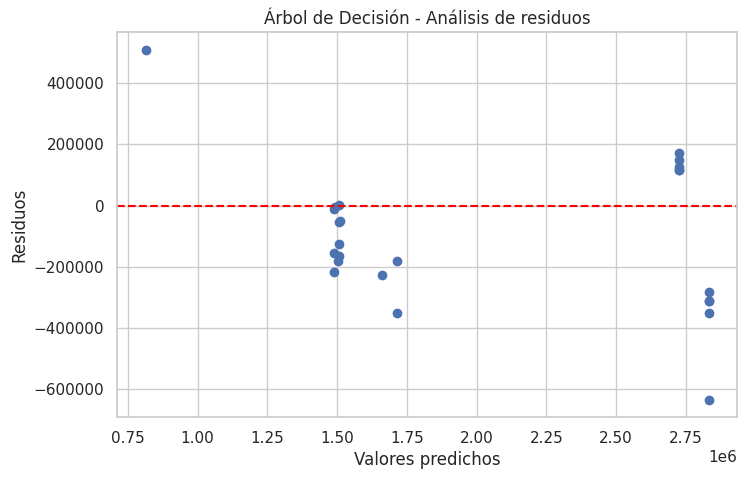

In [ ]:
# ==================================================
# Análisis de residuos
# ==================================================

residuos_dt = y_test - y_pred_dt

plt.figure(figsize=(8,5))

plt.scatter(y_pred_dt, residuos_dt)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Árbol de Decisión - Análisis de residuos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")

plt.show()

# Conclusiones del análisis de residuos

• Los residuos se distribuyen alrededor de la línea de referencia ubicada en cero, indicando que el modelo no presenta un sesgo evidente de sobreestimación o subestimación.

• Se observan errores de distinta magnitud, incluyendo algunos residuos positivos y negativos relativamente elevados, lo que refleja una mayor variabilidad en las predicciones respecto a la Regresión Lineal.

• La concentración de residuos en determinados niveles de predicción es consistente con la estructura propia de los Árboles de Decisión, que generan predicciones por segmentos o regiones del espacio de datos.

• A pesar de estas variaciones, la distribución general de los residuos sugiere que el modelo logra capturar una parte importante del comportamiento del consumo mensual de gas.

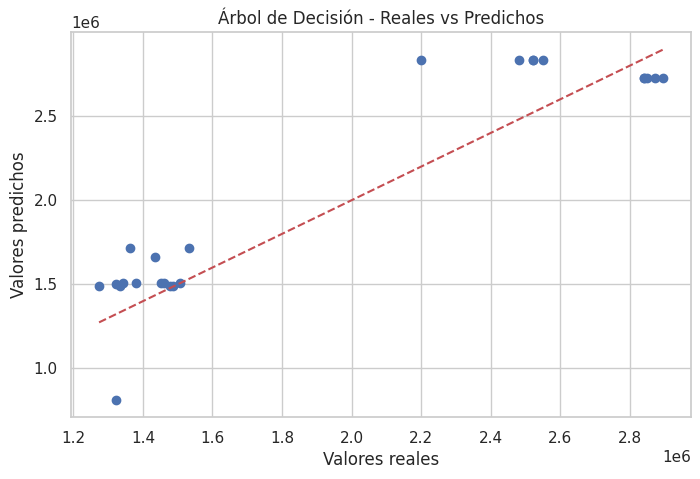

In [ ]:
# ==================================================
# Comparación entre valores reales y predichos
# ==================================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_dt)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Árbol de Decisión - Reales vs Predichos")
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")

plt.show()

# Conclusiones de las predicciones

• Se observa una relación positiva entre los valores reales y los valores predichos, indicando que el modelo logró identificar adecuadamente la tendencia general presente en los datos.

• Las predicciones aparecen agrupadas en determinados niveles de consumo, comportamiento característico de los Árboles de Decisión debido a su estructura basada en particiones sucesivas.

• Los mayores desvíos respecto de la línea ideal se presentan en algunos registros específicos, especialmente en valores de consumo más bajos.

• En términos generales, el modelo reproduce satisfactoriamente los patrones principales del conjunto de prueba, aunque con una precisión ligeramente inferior a la obtenida por la Regresión Lineal.

# Conclusiones de la evaluación del modelo Arbol de Decisión

El Árbol de Decisión obtuvo un coeficiente de determinación R² de aproximadamente 0,84, demostrando una elevada capacidad para explicar la variabilidad observada en el consumo mensual de gas.

Una de las principales ventajas de este modelo es su capacidad para representar relaciones no lineales entre las variables predictoras y la variable objetivo, permitiendo capturar patrones complejos presentes en los datos.

Sin embargo, las métricas de error obtenidas y la dispersión observada en las predicciones indican una estabilidad ligeramente menor respecto a la Regresión Lineal Múltiple.

Considerando conjuntamente las métricas de evaluación, el análisis de residuos y el gráfico de predicción, el Árbol de Decisión se posiciona como una alternativa competitiva, aunque con un desempeño global apenas inferior al modelo lineal seleccionado como solución final.

In [ ]:
# ============================================
# MODELO N°3: Random Forest para Regresión
# ============================================

from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# ============================================
# Predicciones con Random Forest
# ============================================
# Se generan predicciones sobre el conjunto de prueba.
# ============================================

y_pred_rf = modelo_rf.predict(X_test)

In [ ]:
# ============================================
# Evaluación del modelo
# ============================================
# Se calculan métricas para medir el desempeño.
# ============================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

MAE: 254952.84465909086
MSE: 119831742079.1914
RMSE: 346167.21693307615
R²: 0.703976138196492


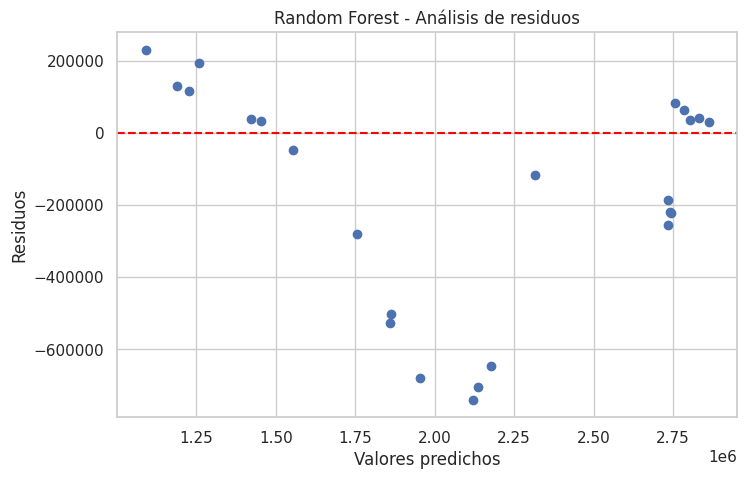

In [ ]:
# ============================================
# Análisis de residuos
# ============================================

residuos_rf = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(y_pred_rf, residuos_rf)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Random Forest - Análisis de residuos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")

plt.show()

# Conclusiones del análisis de residuos

• Los residuos presentan una dispersión considerable alrededor de la línea de referencia ubicada en cero, evidenciando una variabilidad de error superior a la observada en los modelos anteriores.

• Se identifican varios residuos negativos de gran magnitud, indicando que el modelo sobreestimó el consumo en determinados registros del conjunto de prueba.

• La distribución de los errores no resulta tan equilibrada como en la Regresión Lineal, lo que sugiere una menor estabilidad en las predicciones realizadas por el modelo.

• Aunque Random Forest logra capturar parte de la relación existente entre las variables climáticas y el consumo de gas, la amplitud observada en los residuos refleja limitaciones para representar adecuadamente algunos patrones presentes en los datos.

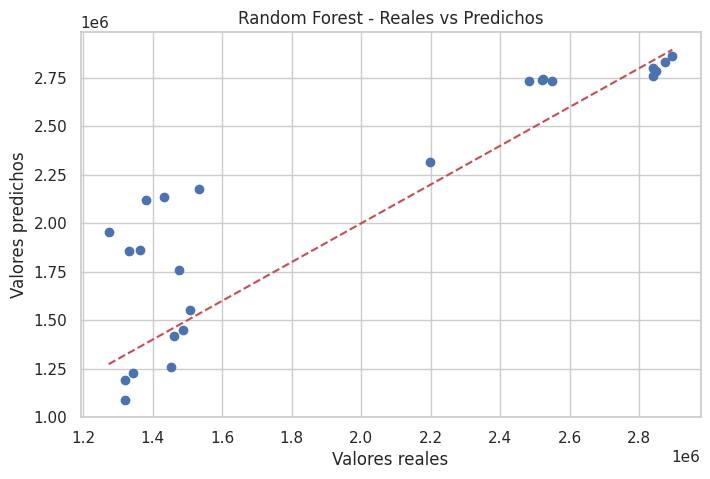

In [ ]:
# ============================================
# Valores reales vs predichos
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Random Forest - Reales vs Predichos")
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")

plt.show()

# Conclusiones del gráfico de predicción

• El modelo reproduce la tendencia general observada en los datos, manteniendo una relación positiva entre los valores reales y los valores predichos.

• Sin embargo, varios registros presentan desviaciones apreciables respecto de la línea ideal de predicción, especialmente en determinados niveles de consumo.

• La dispersión observada es superior a la registrada en la Regresión Lineal y en el Árbol de Decisión, evidenciando una menor precisión predictiva.

• A pesar de estas diferencias, el modelo conserva cierta capacidad para aproximar el comportamiento general del consumo mensual de gas.

• La distribución visual de los puntos resulta consistente con el coeficiente de determinación obtenido durante la evaluación.

# Conclusiones de la evaluación del modelo Random Forest

El modelo Random Forest obtuvo un coeficiente de determinación R² cercano a 0,70, indicando que logra explicar aproximadamente el 70 % de la variabilidad observada en el consumo mensual de gas.

Si bien Random Forest suele destacarse por su capacidad para capturar relaciones complejas y no lineales entre variables, en este conjunto de datos no logró superar el desempeño alcanzado por la Regresión Lineal Múltiple ni por el Árbol de Decisión.

Los valores de MAE y RMSE obtenidos fueron los más elevados entre los modelos evaluados, reflejando una menor precisión en las predicciones realizadas sobre el conjunto de prueba.

Considerando conjuntamente las métricas de evaluación, el gráfico de predicciones y el análisis de residuos, Random Forest resultó ser el modelo con menor capacidad predictiva dentro de los algoritmos analizados para este problema específico.

# Comparación de modelos

Se comparan los modelos desarrollados utilizando las métricas MAE, RMSE y R² obtenidas sobre el conjunto de prueba.

In [ ]:
# ==========================================
# Comparación de modelos
# ==========================================
# Se construye una tabla comparativa con las métricas
# obtenidas por cada modelo evaluado.
# Se incluyen MAE, RMSE y R² para determinar cuál modelo
# presenta mejor desempeño predictivo.
# ==========================================
import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    "R²": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

comparacion

,Modelo,MAE,RMSE,R²
0,Regresión Lineal,192844.838780,246356.614713,0.850072
1,Árbol de Decisión,199675.299242,250714.384506,0.844721
2,Random Forest,254952.844659,346167.216933,0.703976


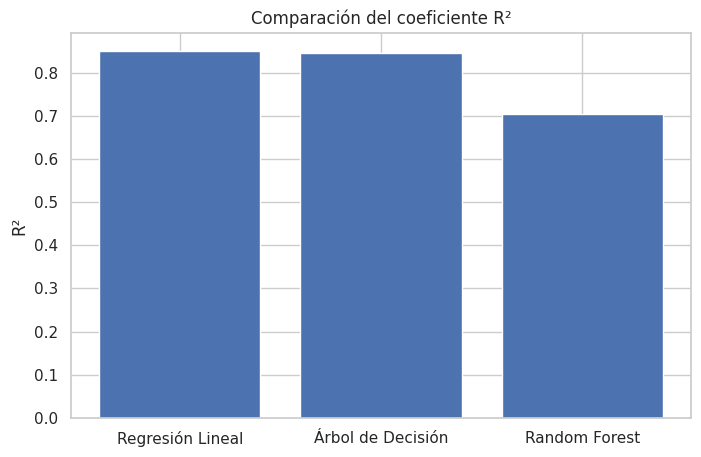

In [ ]:

# ==========================================
# Gráfico comparativo de R²
# ==========================================
# Se visualiza el coeficiente R² de cada modelo.
# Esta métrica permite comparar la proporción de variabilidad
# del consumo de gas explicada por cada algoritmo.
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparacion["Modelo"],
    comparacion["R²"]
)

plt.title("Comparación del coeficiente R²")
plt.ylabel("R²")

plt.show()

#Conclusión de comparación de modelos

La comparación de métricas evidenció que la Regresión Lineal Múltiple obtuvo el mejor desempeño general sobre el conjunto de prueba, alcanzando el mayor coeficiente de determinación (R² = 0,85) y los menores valores de MAE y RMSE entre los modelos evaluados.

El Árbol de Decisión presentó resultados competitivos, con métricas cercanas a las obtenidas por la Regresión Lineal Multiple. Sin embargo, mostró una ligera disminución en la capacidad de generalización, reflejada en un R² levemente inferior y errores de predicción algo mayores.

Por su parte, Random Forest obtuvo el menor desempeño relativo en esta validación temporal, registrando un R² cercano a 0,70 y mayores valores de error. Aunque logró capturar la tendencia general del consumo de gas, presentó una mayor dispersión entre los valores reales y predichos.

Considerando conjuntamente las métricas de evaluación, el análisis gráfico de las predicciones, el comportamiento de los residuos y la interpretabilidad de los resultados, la Regresión Lineal Múltiple fue seleccionada como modelo final del proyecto, al ofrecer el mejor equilibrio entre precisión predictiva y capacidad de explicación de los factores que influyen en el consumo mensual de gas envasado.

In [ ]:
# ==========================================
# Comparación de predicciones individuales
# ==========================================
# Se construye una tabla con valores reales y predichos
# por cada modelo.
# Esta tabla permite observar diferencias puntuales entre
# las estimaciones de Regresión Lineal, Árbol de Decisión
# y Random Forest.
# ==========================================

comparacion_predicciones = pd.DataFrame({
    "Real": y_test,
    "Regresión Lineal": y_pred_lr,
    "Árbol de Decisión": y_pred_dt,
    "Random Forest": y_pred_rf
})

# Se redondean los valores para mejorar la visualización
comparacion_predicciones = comparacion_predicciones.round(0).astype(int)

comparacion_predicciones.head(10)

,Real,Regresión Lineal,Árbol de Decisión,Random Forest
120,1460855,1351518,1510564,1421226
121,1486220,1479489,1490557,1451899
122,1507445,1779901,1505818,1553751
123,1532726,2154245,1713818,2177544
124,2840416,2570096,2725206,2757511
125,2895266,3198372,2725206,2863902
126,2840208,2961464,2725206,2802793
127,2872820,2985315,2725206,2831333
128,2849464,2700971,2725206,2785529
129,1476842,2107415,1489428,1756797


In [ ]:
# ============================================
# Importancia de variables - Regresión Lineal
# ============================================
# Como la Regresión Lineal Múltiple fue seleccionada como modelo final,
# se analizan los coeficientes del modelo para interpretar la influencia
# relativa de cada variable predictora.
#
# Al haberse aplicado StandardScaler, los coeficientes son comparables
# entre sí. Se utiliza el valor absoluto del coeficiente para identificar
# qué variables tienen mayor peso en la predicción.
# ============================================

import pandas as pd

importancias_lr = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr.coef_,
    "Importancia": abs(modelo_lr.coef_)
})

importancias_lr = importancias_lr.sort_values(
    by="Importancia",
    ascending=False
)

importancias_lr.head(10)

,Variable,Coeficiente,Importancia
3,temp_min_rg,306776.126654,306776.126654
1,cantidad_usuarios,270446.583977,270446.583977
0,año,215882.026941,215882.026941
14,mes_cos,-212974.344832,212974.344832
7,temp_max_ush,-207960.364999,207960.364999
4,temp_media_rg,-161205.497424,161205.497424
2,temp_max_rg,-153920.268999,153920.268999
13,mes_sin,-143044.720893,143044.720893
8,temp_min_ush,-128349.965978,128349.965978
9,temp_media_ush,93520.212155,93520.212155


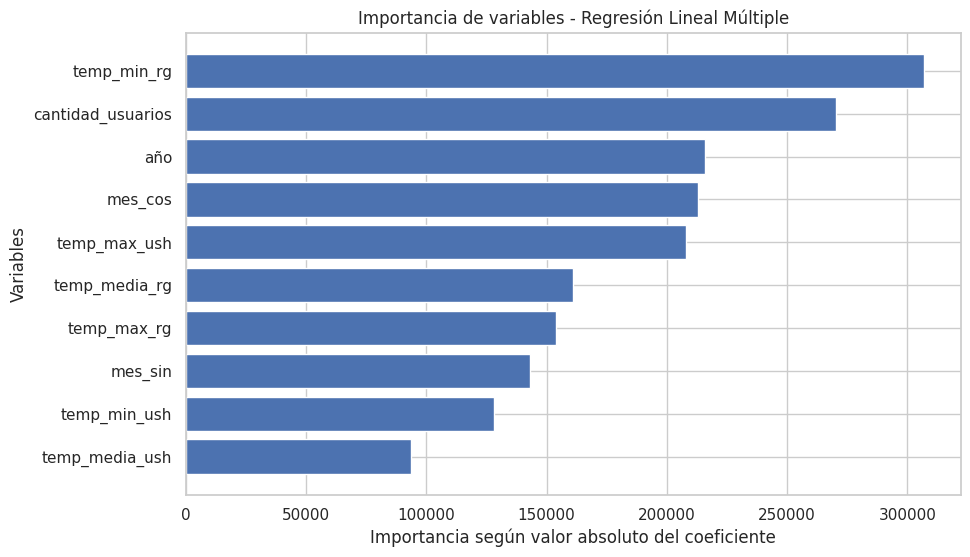

In [ ]:
# ============================================
# Gráfico de importancia de variables
# Regresión Lineal Múltiple
# ============================================
# Se representan las variables con mayor peso
# dentro del modelo de Regresión Lineal.
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importancias_lr["Variable"].head(10),
    importancias_lr["Importancia"].head(10)
)

plt.title("Importancia de variables - Regresión Lineal Múltiple")
plt.xlabel("Importancia según valor absoluto del coeficiente")
plt.ylabel("Variables")

plt.gca().invert_yaxis()

plt.show()

# Conclusiones de la importancia de variables

- La importancia de variables fue analizada a partir de los coeficientes de la Regresión Lineal Múltiple, modelo seleccionado como final debido a su mejor desempeño general.

- Debido a que las variables fueron escaladas previamente, los coeficientes resultan comparables entre sí y permiten interpretar la influencia relativa de cada predictor sobre el consumo mensual de gas.

- La temperatura mínima de Río Grande fue la variable con mayor influencia dentro de la Regresión Lineal Múltiple. También se destacaron la cantidad de usuarios subsidiados, la variable temporal asociada al año y las variables cíclicas utilizadas para representar la estacionalidad mensual.

- Las variables de temperatura de Río Grande y Ushuaia también presentaron una contribución relevante, lo que confirma la influencia de las condiciones climáticas sobre el consumo de gas envasado.

- La presencia de las variables mes_sin y mes_cos entre los predictores relevantes indica que la estacionalidad anual también aporta información al modelo.

- En conjunto, los resultados confirman que las condiciones climáticas, la evolución temporal de la demanda y la cantidad de usuarios constituyen los principales factores explicativos del consumo mensual de gas envasado en Tierra del Fuego.

# Conclusión final del proyecto
El presente proyecto tuvo como objetivo desarrollar modelos de Aprendizaje Automático capaces de predecir el consumo mensual de gas envasado en la provincia de Tierra del Fuego a partir de variables climáticas, temporales y operativas. Para ello se integraron datos históricos de consumo energético con información meteorológica correspondiente a las ciudades de Río Grande y Ushuaia, aplicando previamente tareas de limpieza, transformación, integración e imputación de valores faltantes.

Durante la etapa exploratoria se identificó una relación significativa entre el consumo de gas y las condiciones climáticas, especialmente con las variables de temperatura. Los análisis realizados evidenciaron que los períodos con menores temperaturas se asocian a mayores niveles de consumo, lo que confirma la influencia de los factores meteorológicos sobre la demanda energética provincial.

Posteriormente se implementaron tres modelos de regresión supervisada: Regresión Lineal Múltiple, Árbol de Decisión y Random Forest. La evaluación se realizó mediante una división temporal del conjunto de datos, utilizando los registros históricos para entrenamiento y los años más recientes para validación, con el objetivo de simular un escenario real de predicción futura.

Los resultados obtenidos mostraron que la Regresión Lineal Múltiple y el Árbol de Decisión alcanzaron desempeños muy similares sobre el conjunto de prueba. Sin embargo, la Regresión Lineal obtuvo los mejores indicadores globales de desempeño, alcanzando un R² de 0,85 y los menores valores de MAE y RMSE, por lo que se consideró el modelo con mejor desempeño general. Por su parte, el Árbol de Decisión presentó métricas cercanas, mientras que Random Forest evidenció una menor capacidad predictiva para este conjunto de datos, obteniendo un R² aproximado de 0,70.

El análisis de los coeficientes de la Regresión Lineal Múltiple indicó que la
temperatura mínima de Río Grande fue la variable de mayor influencia dentro del modelo. También se destacaron la cantidad de usuarios subsidiados, la variable temporal asociada al año y las variables cíclicas utilizadas para representar la estacionalidad mensual. La relevancia de las variables mes_sin y mes_cos demuestra que la codificación cíclica permitió representar adecuadamente el comportamiento estacional del consumo de gas a lo largo del año. Estos resultados confirman que los factores climáticos y temporales desempeñan un papel fundamental en la predicción del consumo mensual de gas envasado.

Los análisis de residuos y la comparación entre valores reales y predichos permitieron verificar que la Regresión Lineal reproduce adecuadamente la tendencia general observada en los datos, sin presentar patrones de error sistemáticos relevantes. Esto sugiere que el modelo posee una adecuada capacidad de generalización para realizar estimaciones sobre períodos futuros.

En conclusión, los resultados demuestran que la incorporación de variables climáticas permite modelar de manera efectiva el comportamiento del consumo mensual de gas envasado en Tierra del Fuego. Dentro de los modelos evaluados, la Regresión Lineal Múltiple fue seleccionada como modelo final debido a que obtuvo el mejor desempeño general sobre el conjunto de prueba, alcanzando los mayores valores de R² y los menores errores de predicción. Además, presentó una adecuada capacidad de generalización e interpretabilidad de los resultados. Aunque el Árbol de Decisión presentó un desempeño muy cercano, la Regresión Lineal logró los mejores indicadores globales de evaluación sobre el conjunto de prueba. Estos hallazgos evidencian el potencial de las técnicas de Aprendizaje Automático como herramientas de apoyo para la planificación energética y la toma de decisiones basada en datos.